# <center>⚡️🏁 Quick start - тестируем простое решение</center>

In [17]:
# !pip install numpy pandas catboost -q
# !ls ../data/ # проверяем наличие данных

In [18]:
import numpy as np
import pandas as pd

## Анализируем данные о машинах car_info

🚗 Главное описание машин с информацией о поломках для обучения / прогноза - `car_train.csv` / `car_test.csv`.

**Пояснение столбцов:**
- `car_id` - идентификатор машины
- `model` / `car_type` / `fuel_type`- марка, класс и тип топлива машины
- `car_rating` / `riders` - общий рейтинг и общее число поездок к концу 2021-го кода.
- `year_to_start` / `year_to_work` - годы выпуска машины и начала работы в автопарке 
- `target_reg` - количество дней до поломки.
- `target_class` - класс поломки (всего 9 видов)

(2337, 10)


,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class
1781,q15127304Z,Nissan Qashqai,standart,petrol,4.16,2015,72269,2021,56.66,engine_ignition
791,m-2205063P,Smart ForFour,economy,petrol,5.10,2013,46222,2016,74.88,another_bug
1404,f-1958284u,VW Polo VI,economy,petrol,4.96,2011,5779,2020,82.84,another_bug


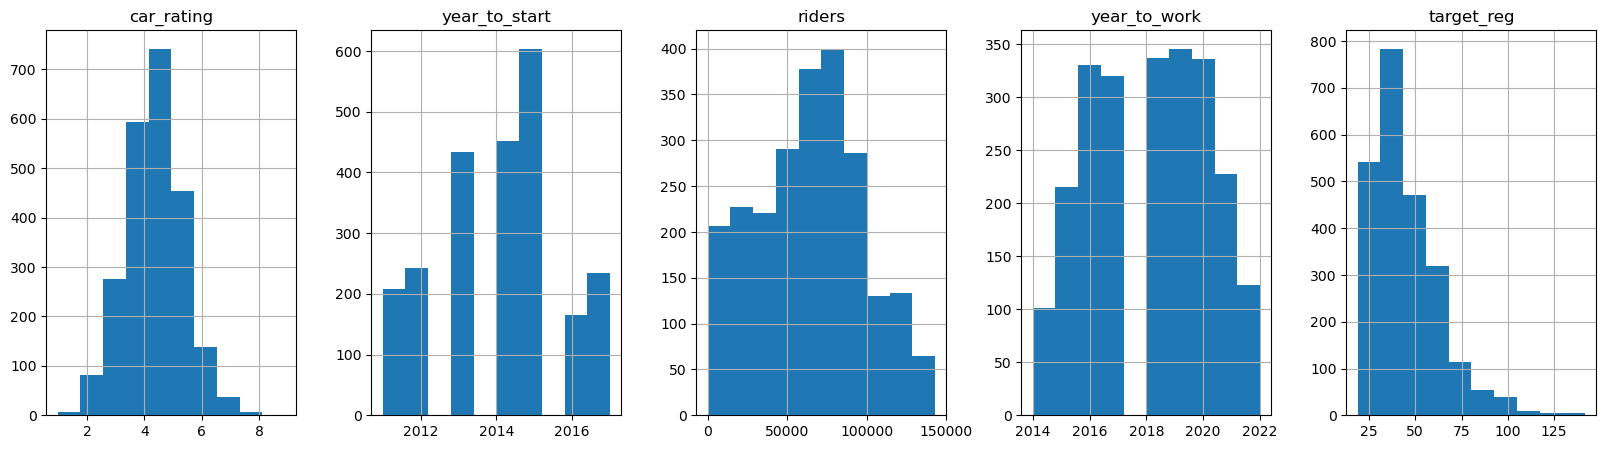

In [19]:
path = '../data/car_train.csv'
train = pd.read_csv(path)
print(train.shape)
train.hist(figsize=(20, 5), layout = (-1, 5))
train.sample(3)

In [20]:
train.describe()

,car_rating,year_to_start,riders,year_to_work,target_reg
count,2337.000000,2337.000000,2337.000000,2337.000000,2337.000000
mean,4.354292,2014.040650,63711.443731,2018.069748,44.946735
std,0.996954,1.685852,33755.012096,2.159484,17.579568
min,0.980000,2011.000000,23.000000,2014.000000,18.920000
25%,3.740000,2013.000000,41053.000000,2016.000000,31.670000
50%,4.360000,2014.000000,64415.000000,2018.000000,40.170000
75%,5.000000,2015.000000,86515.000000,2020.000000,54.790000
max,8.900000,2017.000000,142862.000000,2022.000000,141.630000


In [21]:
path = '../data/car_test.csv'
test = pd.read_csv(path)
print(test.shape)
test.sample(3)

(1913, 8)


,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work
482,v-1905656K,VW Polo,economy,petrol,4.54,2015,75827,2015
1163,J-2100035F,Smart Coupe,economy,petrol,4.00,2015,87477,2018
141,M-1236720D,Smart ForTwo,economy,petrol,4.70,2014,57558,2019


## Классифицируем признаки на типы

In [22]:
features2drop = ['car_id'] # то, что надо выбросить 
targets = ['target_class', 'target_reg'] # таргеты
cat_features = ['car_type', 'fuel_type', 'model'] # категориальные признаки

filtered_features = [i for i in train.columns if (i not in targets and i not in features2drop)]
num_features = [i for i in filtered_features if i not in cat_features]

print('cat_features :', len(cat_features), cat_features)
print('num_features :', len(num_features), num_features)
print('targets', targets)

cat_features : 3 ['car_type', 'fuel_type', 'model']
num_features : 4 ['car_rating', 'year_to_start', 'riders', 'year_to_work']
targets ['target_class', 'target_reg']


## Обучаем Catboost и делаем прогноз на тест

In [23]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score #, mean_squared_error

In [24]:
X = train[filtered_features].drop(targets, axis=1, errors='ignore')
y = train['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = CatBoostClassifier(cat_features=cat_features)


clf.fit(X_train, y_train, 
          eval_set=(X_test, y_test),
          verbose=150, plot=False)

# инференс модели
y_pred = clf.predict(X_test)
print(f'\n Accuracy: {accuracy_score(y_test, y_pred)}')

Learning rate set to 0.109335
0:	learn: 2.1911361	test: 2.1951349	best: 2.1951349 (0)	total: 18ms	remaining: 18s
150:	learn: 1.6539682	test: 2.2440578	best: 2.1908935 (6)	total: 2.95s	remaining: 16.6s
300:	learn: 1.2455381	test: 2.3306861	best: 2.1908935 (6)	total: 5.97s	remaining: 13.9s
450:	learn: 0.9655173	test: 2.4024298	best: 2.1908935 (6)	total: 8.99s	remaining: 10.9s
600:	learn: 0.7488971	test: 2.4913589	best: 2.1908935 (6)	total: 12.2s	remaining: 8.1s
750:	learn: 0.5826318	test: 2.5762847	best: 2.1908935 (6)	total: 15.6s	remaining: 5.16s
900:	learn: 0.4643456	test: 2.6651694	best: 2.1908935 (6)	total: 18.7s	remaining: 2.05s
999:	learn: 0.4027101	test: 2.7091668	best: 2.1908935 (6)	total: 21s	remaining: 0us

bestTest = 2.19089351
bestIteration = 6

Shrink model to first 7 iterations.

 Accuracy: 0.0876068376068376


In [25]:
test['target_class'] = clf.predict(test[filtered_features]).ravel()
test[['car_id', 'target_class']].to_csv('../subs/simple_baseline_v1.csv', index=False)
print('CSV file saved!')

CSV file saved!


## Добавим информацию про поездки из rides_info


🏇 Информация про поездки - `rides_info.csv`.  **Пояснение столбцов:**
- `user_id` / `car_id` / `ride_id` - идентификаторы водителя, машины, поездки соответственно
- `ride_date` / `rating` - дата поездки и рейтинг, поставленный водителем 
- `ride_duration` / `distance` / `ride_cost` -  длительность (время),  пройденное расстояние, стоимость поездки 
- `speed_avg` / `speed_max` - средняя и максимальная скорости поездки соответственно
- `stop_times` / `refueling` - количество остановок (паузы) и флаг - была ли дозаправка.
- `user_ride_quality` - оценка манеры вождения машины водителя, определенная скоринговой ML системой сервиса.
- `deviation_normal` - общий показатель датчиков о состоянии машины, относительно эталонных показателей (нормы). 


In [26]:
path = '../data/rides_info.csv'
rides = pd.read_csv(path)
rides.sample(5)

,user_id,car_id,ride_id,ride_date,rating,ride_duration,ride_cost,speed_avg,speed_max,stop_times,distance,refueling,user_ride_quality,deviation_normal
380698,v13187334X,b-1441595E,X1X,2020-03-25,6.53,47,2345,40,75.0,2,1956.524079,0,6.687070,-11.218
121050,i13337141O,I13894787U,v1T,2020-03-04,6.08,45,579,34,59.0,1,1520.796786,0,5.539144,-2.857
268663,Z21557969j,S19803153J,a1w,2020-01-04,4.60,127,1391,36,63.0,9,2849.690503,0,1.768604,-2.574
525106,h22600164H,l-1076081s,b1M,2020-03-19,3.87,170,2375,51,79.0,0,863.210077,0,24.307891,11.250
67563,D54958867b,E22476230A,E1R,2020-01-28,6.10,34,401,42,67.0,1,1137.058230,0,-1.968963,4.724


In [27]:
f = lambda x: x.nunique()
rides_df_gr = rides.groupby('car_id', as_index=False).agg(mean_rating = ('rating', 'mean'),
                                                   distance_sum = ('distance', 'sum'),
                                                   rating_min = ('rating', 'min'),
                                                   speed_max = ('speed_max', 'max'),
                                                   user_ride_quality_median = ('user_ride_quality', 'median'), 
                                                   deviation_normal_count = ('deviation_normal', 'count'),
                                                   user_uniq = ('user_id', f))


rides_df_gr.head(2)

,car_id,mean_rating,distance_sum,rating_min,speed_max,user_ride_quality_median,deviation_normal_count,user_uniq
0,A-1049127W,4.255172,1.125753e+07,0.1,179.729652,-0.288229,174,172
1,A-1079539w,4.088046,1.912765e+07,0.1,184.505566,2.508746,174,173


In [28]:
def add_featues(df):
    
    if 'mean_rating' not in df.columns:
        return df.merge(rides_df_gr, on = 'car_id', how = 'left')
    
    return df
    
    
train = add_featues(train)
test = add_featues(test)

In [29]:
train.sample(2)

,car_id,model,car_type,fuel_type,car_rating,year_to_start,riders,year_to_work,target_reg,target_class,mean_rating,distance_sum,rating_min,speed_max,user_ride_quality_median,deviation_normal_count,user_uniq
1780,i-2071885N,Smart ForTwo,economy,petrol,6.32,2015,85858,2018,63.00,engine_ignition,4.269310,1.074764e+07,0.10,187.418937,-0.397453,174,174
2197,r-2233973m,Renault Sandero,standart,petrol,5.52,2013,41067,2021,34.64,break_bug,5.205057,1.886724e+07,0.38,106.742442,-14.011833,174,173


In [30]:
train.to_csv('../data/quickstart_train.csv', index=False)

In [31]:
test.to_csv('../data/quickstart_test.csv', index=False)

# Снова обновляем типы фичей

In [32]:
filtered_features = [i for i in train.columns if (i not in targets and i not in features2drop)]
num_features = [i for i in filtered_features if i not in cat_features]


print('num_features :', len(num_features), num_features)
print('cat_features :', len(cat_features), cat_features)
print('targets', targets)

num_features : 11 ['car_rating', 'year_to_start', 'riders', 'year_to_work', 'mean_rating', 'distance_sum', 'rating_min', 'speed_max', 'user_ride_quality_median', 'deviation_normal_count', 'user_uniq']
cat_features : 3 ['car_type', 'fuel_type', 'model']
targets ['target_class', 'target_reg']


# Обучаем Catboost на новых данных и делаем новый прогноз

In [33]:
X = train[filtered_features].drop(targets, axis=1, errors='ignore')
y = train['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = CatBoostClassifier(cat_features=cat_features)


clf.fit(X_train, y_train, 
          eval_set=(X_test, y_test),
          verbose=150, plot=False)

# инференс модели
y_pred = clf.predict(X_test)
print(f'\n Accuracy: {accuracy_score(y_test, y_pred)}')

Learning rate set to 0.109335
0:	learn: 1.8475119	test: 1.8655808	best: 1.8655808 (0)	total: 19.6ms	remaining: 19.5s
150:	learn: 0.3200590	test: 0.5547029	best: 0.5540463 (147)	total: 3.32s	remaining: 18.7s
300:	learn: 0.1971982	test: 0.5615205	best: 0.5513186 (167)	total: 6.81s	remaining: 15.8s
450:	learn: 0.1375334	test: 0.5712868	best: 0.5513186 (167)	total: 10.2s	remaining: 12.4s
600:	learn: 0.0980050	test: 0.5823510	best: 0.5513186 (167)	total: 13.6s	remaining: 9.05s
750:	learn: 0.0738682	test: 0.5989975	best: 0.5513186 (167)	total: 17.1s	remaining: 5.67s
900:	learn: 0.0569120	test: 0.6151325	best: 0.5513186 (167)	total: 20.5s	remaining: 2.25s
999:	learn: 0.0495492	test: 0.6233229	best: 0.5513186 (167)	total: 22.9s	remaining: 0us

bestTest = 0.5513186112
bestIteration = 167

Shrink model to first 168 iterations.

 Accuracy: 0.782051282051282


In [34]:
fi = clf.get_feature_importance(prettified=True)
fi

,Feature Id,Importances
0,speed_max,36.034645
1,mean_rating,30.903684
2,rating_min,13.938537
3,model,4.206258
4,car_type,3.881288
5,user_uniq,3.035950
6,user_ride_quality_median,2.097702
7,distance_sum,1.614279
8,riders,1.347984
9,car_rating,1.149331


In [35]:
test['target_class'] = clf.predict(test[filtered_features]).ravel()
test[['car_id', 'target_class']].to_csv('../subs/simple_baseline_v2.csv', index=False)
print('CSV file saved!')

CSV file saved!


# Что дальше? Зашли решение на Kaggle

- Нажимаем `Save Version`
- Проверяем, что в `Advanced Settings` выбрано - всегда сохранять результаты ноутбука.
- Тип сохранения `Save & Run All (Commit)`
- Жмем окончательно кнопку `Save`

In [ ]:
# !pip install orbit-ml -q
# !pip install fastparquet
# !pip install msgpack-python
# !pip install mysql-connector-python
# !pip install psycopg2
# !pip install opencv-python
# !pip install geopandas folium -q
# !pip install karateclub -q
# !pip install tsfresh -q
# !pip install pymorphy2 -q
# !pip install selenium -q
# !pip install transformers sentencepiece sentence-transformers simpletransformers -q 
# !pip install --upgrade -q wandb
# !pip install phik
# !pip install shap
# !pip install pandarallel
# !pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128

  error: subprocess-exited-with-error
  
  × Building wheel for orbit-ml (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [545 lines of output]
      C:\Users\pong\AppData\Local\Temp\pip-build-env-g_yry8e0\overlay\Lib\site-packages\setuptools\_distutils\dist.py:289: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      C:\Users\pong\AppData\Local\Temp\pip-build-env-g_yry8e0\overlay\Lib\site-packages\setuptools\_distutils\dist.py:289: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\pong\AppData\Local\Temp\pip-build-env-g_yry8e0\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsWarning: `install_requires` overwritten in `pyproject.toml` (dependencies)
        corresp(dist, value, root_dir)
      C:\Users\pong\AppData\Local\Temp\pip-build-env-g_yry8e0\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `pro

   ---------------------------------------- 0.0/673.3 kB ? eta -:--:--
   ---------------------------------------- 673.3/673.3 kB 6.5 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 9.3 MB/s  0:00:00

   ---------------------------------------- 2/2 [fastparquet]

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for msgpack-python: filename=msgpack_python-0.5.6-cp312-cp312-win_amd64.whl size=10487 sha256=9bd1b2d42a1592573f8d463ad58064de8120d87bdf7258d681e480ee6ec120e0
  Stored in directory: c:\users\pong\appdata\local\pip\cache\wheels\77\19\55\59bd61a1d7d25e9177a8d6d037d6ea039c208c89b12d1418c5
Successfully 

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "C:\Users\pong\anaconda3\envs\ml\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "C:\Users\pong\anaconda3\envs\ml\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\pong\anaconda3\envs\ml\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 137, in get_requires_for_build_wheel
          backend = _build_backend()
                    ^^^^^^^^^^^^^^^^
        File "C:\Users\pong\anaconda3\envs\ml\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 70, in _build_back

In [2]:
import pandas as pd

In [ ]:
# !pip install torch torchvision torchaudio --no-warn-script-location
# !pip install pytorch-tabnet -q
# !pip install "etna[prophet]" -q --use-deprecated=legacy-resolver
# !pip install etna -q
# !pip install boruta -q
# !pip install boostaroota -q


In [ ]:
# !conda install karateclub > _

In [ ]:
# !pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.8 MB 11.2 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.8 MB 11.2 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 11.3 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 11.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 11.6 MB/s  0:00:00

   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   -------------------- ------------------- 1/2 [torchaudio]
   -------------------- ------------------- 1/2 [torchaudio]
   ---------------------------

'1.41.2'